In [ ]:
# Install required libraries
!pip install librosa numpy scikit-learn joblib

# Import required libraries
import os
import numpy as np
import librosa
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from google.colab import drive

In [ ]:
drive.mount('/content/drive')
dataset_path = "/content/drive/My Drive/Speech_Commands/speech_commands_v0.02"

Mounted at /content/drive


In [ ]:
# Function to extract MFCC features
def extract_mfcc(file_path, max_pad_len=32):
    audio, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)

    # Pad or truncate to fixed length
    if mfcc.shape[1] < max_pad_len:
        pad_width = max_pad_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0, 0), (0, pad_width)), mode="constant")
    else:
        mfcc = mfcc[:, :max_pad_len]

    return mfcc

In [ ]:
labels = []
features = []

for label in ["on", "off"]:
    folder_path = os.path.join(dataset_path, label)
    if not os.path.exists(folder_path):
        print(f"⚠️ Folder not found: {label}")
        continue
    print(f"🔍 Processing: {label}")

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        try:
            mfcc = extract_mfcc(file_path)
            features.append(mfcc)
            labels.append(label)
        except Exception as e:
            print(f"❌ Error processing {file}: {e}")

# Convert to NumPy arrays
X = np.array(features)
y = np.array(labels)

# Encode labels ("on" → 1, "off" → 0)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Save processed data
np.save("X_mfcc.npy", X)
np.save("y_labels.npy", y_encoded)
print("✅ Data Preprocessing Completed & Saved!")


⚠️ Folder not found: on
⚠️ Folder not found: off
✅ Data Preprocessing Completed & Saved!


In [ ]:
dataset_path = "/content/drive/My Drive/Speech_Commands/speech_commands_v0.02/Simple Commands"

In [ ]:
labels = []
features = []

for label in ["on", "off"]:
    folder_path = os.path.join(dataset_path, label)
    if not os.path.exists(folder_path):
        print(f"⚠️ Folder not found: {label}")
        continue
    print(f"🔍 Processing: {label}")

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        try:
            mfcc = extract_mfcc(file_path)
            features.append(mfcc)
            labels.append(label)
        except Exception as e:
            print(f"❌ Error processing {file}: {e}")

⚠️ Folder not found: on
⚠️ Folder not found: off


In [ ]:
import os

base_path = "/content/drive/My Drive/Speech_Commands"
print("📂 Contents of Speech_Commands folder:")
print(os.listdir(base_path))

📂 Contents of Speech_Commands folder:
['speech_commands_v0.02.tar.gz', 'dataset', 'FYP.testipynb', 'FYP.ipynb']


In [ ]:
import shutil

src_path = "/content/drive/My Drive/Speech_Commands/speech_commands_v0.02.tar.gz"
dst_path = "/content/speech_commands_v0.02.tar.gz"

shutil.copy(src_path, dst_path)
print("✅ File copied to /content.")

✅ File copied to /content.


In [ ]:
import tarfile

tar_path = "/content/speech_commands_v0.02.tar.gz"
extract_path = "/content/speech_commands"

with tarfile.open(tar_path, "r:gz") as tar:
    tar.extractall(path=extract_path)

print("✅ Extraction complete in /content!")

✅ Extraction complete in /content!


In [ ]:
import os
print("📂 Available folders:")
print(os.listdir("/content/speech_commands"))

📂 Available folders:
['four', 'off', 'no', 'marvin', 'seven', 'stop', 'tree', 'sheila', 'follow', 'learn', 'eight', 'backward', 'up', 'bed', 'yes', 'bird', 'validation_list.txt', 'dog', 'visual', 'README.md', 'happy', 'zero', 'right', 'on', 'nine', 'forward', 'down', 'cat', 'two', 'testing_list.txt', 'go', 'six', 'left', '_background_noise_', '.DS_Store', 'LICENSE', 'three', 'one', 'house', 'wow', 'five']


In [ ]:
dataset_path = "/content/speech_commands"

In [ ]:
import numpy as np
import os
import librosa
from sklearn.preprocessing import LabelEncoder

labels = []
features = []

def extract_mfcc(file_path, max_pad_len=32):
    audio, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)

    # Pad or trim to the same length
    if mfcc.shape[1] < max_pad_len:
        pad_width = max_pad_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0, 0), (0, pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_pad_len]

    return mfcc

# Only process 'on' and 'off'
for label in ['on', 'off']:
    folder_path = os.path.join(dataset_path, label)
    print(f"🔍 Processing folder: {label}")

    if not os.path.exists(folder_path):
        print(f"❌ Folder not found: {label}")
        continue

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        try:
            mfcc = extract_mfcc(file_path)
            features.append(mfcc)
            labels.append(label)
        except Exception as e:
            print(f"⚠️ Skipped {filename}: {e}")

# Convert to NumPy arrays
X = np.array(features)
y = np.array(labels)

# Encode labels (on = 1, off = 0)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Save preprocessed data
np.save("X_mfcc.npy", X)
np.save("y_labels.npy", y_encoded)

print("✅ Preprocessing completed and saved!")

🔍 Processing folder: on
🔍 Processing folder: off
✅ Preprocessing completed and saved!


In [ ]:
import os
import numpy as np
import librosa
from sklearn.preprocessing import LabelEncoder

# Dataset path
dataset_path = "/content/speech_commands"

labels = []
features = []

def extract_mfcc(file_path, max_pad_len=32):
    audio, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    if mfcc.shape[1] < max_pad_len:
        pad_width = max_pad_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0, 0), (0, pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_pad_len]
    return mfcc

max_samples_per_class = 500

for label in ['on', 'off']:
    folder_path = os.path.join(dataset_path, label)
    print(f"🔍 Processing folder: {label}")

    if not os.path.exists(folder_path):
        print(f"❌ Folder not found: {label}")
        continue

    files = os.listdir(folder_path)[:max_samples_per_class]

    for filename in files:
        file_path = os.path.join(folder_path, filename)
        try:
            mfcc = extract_mfcc(file_path)
            features.append(mfcc)
            labels.append(label)
        except Exception as e:
            print(f"⚠️ Skipped {filename}: {e}")

X = np.array(features)
y = np.array(labels)

# Encode 'on' and 'off' to 1 and 0
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Save processed data
np.save("X_mfcc.npy", X)
np.save("y_labels.npy", y_encoded)

print("✅ Preprocessing completed and saved!")


🔍 Processing folder: on
🔍 Processing folder: off
✅ Preprocessing completed and saved!


In [ ]:
max_samples_per_class = 500  # Reduce to speed up training

for label in ['on', 'off']:
    folder_path = os.path.join(dataset_path, label)
    print(f"🔍 Processing folder: {label}")

    files = os.listdir(folder_path)[:max_samples_per_class]  # Limit files

    for filename in files:
        file_path = os.path.join(folder_path, filename)
        try:
            mfcc = extract_mfcc(file_path)
            features.append(mfcc)
            labels.append(label)
        except Exception as e:
            print(f"⚠️ Skipped {filename}: {e}")


🔍 Processing folder: on
🔍 Processing folder: off


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Load preprocessed data
X = np.load("X_mfcc.npy")
y = np.load("y_labels.npy")

# Flatten MFCCs
X_flat = X.reshape(X.shape[0], -1)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_flat, y, test_size=0.2, random_state=42)

print(f"🧠 Training samples: {len(X_train)} | 🧪 Testing samples: {len(X_test)}")

# Train SVM
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("📊 SVM Results:")
print(classification_report(y_test, y_pred_svm))
print("✅ Accuracy:", accuracy_score(y_test, y_pred_svm))

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("🌲 Random Forest Results:")
print(classification_report(y_test, y_pred_rf))
print("✅ Accuracy:", accuracy_score(y_test, y_pred_rf))

🧠 Training samples: 800 | 🧪 Testing samples: 200
📊 SVM Results:
              precision    recall  f1-score   support

           0       0.72      0.76      0.74       104
           1       0.73      0.69      0.71        96

    accuracy                           0.72       200
   macro avg       0.73      0.72      0.72       200
weighted avg       0.73      0.72      0.72       200

✅ Accuracy: 0.725
🌲 Random Forest Results:
              precision    recall  f1-score   support

           0       0.87      0.84      0.85       104
           1       0.83      0.86      0.85        96

    accuracy                           0.85       200
   macro avg       0.85      0.85      0.85       200
weighted avg       0.85      0.85      0.85       200

✅ Accuracy: 0.85


In [ ]:
import joblib

joblib.dump(rf_model, "smart_light_model.pkl")
print("💾 Model saved successfully!")

💾 Model saved successfully!


In [ ]:
# Load model
model = joblib.load("smart_light_model.pkl")

# Predict from a new sample
def predict_voice_command(file_path):
    mfcc = extract_mfcc(file_path)
    mfcc_flat = mfcc.flatten().reshape(1, -1)
    prediction = model.predict(mfcc_flat)[0]
    command = encoder.inverse_transform([prediction])[0]

    print(f"🗣️ Command detected: {command}")
    if command == "on":
        print("💡 Light turned ON.")
    else:
        print("💡 Light turned OFF.")

# 🔊 Test sample
predict_voice_command("/content/speech_commands/on/01bb6a2a_nohash_0.wav")

🗣️ Command detected: on
💡 Light turned ON.


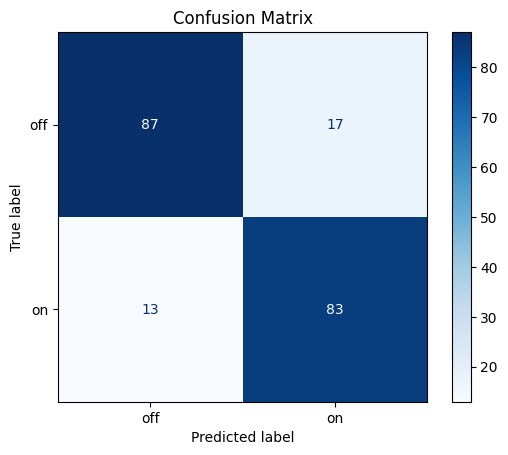

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on test set again
y_pred = rf_model.predict(X_test)

# Show confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
print("✅ Final Accuracy:", accuracy_score(y_test, y_pred))

✅ Final Accuracy: 0.85


In [ ]:
for label in ['on', 'off', 'stop']:  # Add 'stop' here
    folder_path = os.path.join(dataset_path, label)
    print(f"🔍 Processing folder: {label}")

    files = os.listdir(folder_path)[:max_samples_per_class]

    for filename in files:
        file_path = os.path.join(folder_path, filename)
        try:
            mfcc = extract_mfcc(file_path)
            features.append(mfcc)
            labels.append(label)
        except Exception as e:
            print(f"⚠️ Skipped {filename}: {e}")

🔍 Processing folder: on
🔍 Processing folder: off
🔍 Processing folder: stop


In [ ]:
import librosa
import numpy as np
import os
import random
from scipy.io import wavfile

In [ ]:
background_path = os.path.join(dataset_path, "_background_noise_")
background_files = [f for f in os.listdir(background_path) if f.endswith(".wav")]

print("🎧 Available background noise files:", background_files)

# Load all background noises into memory
background_noises = []

for noise_file in background_files:
    file_path = os.path.join(background_path, noise_file)
    try:
        noise, sr = librosa.load(file_path, sr=16000)
        background_noises.append(noise)
    except Exception as e:
        print(f"⚠️ Error loading {noise_file}: {e}")

🎧 Available background noise files: ['running_tap.wav', 'exercise_bike.wav', 'doing_the_dishes.wav', 'pink_noise.wav', 'dude_miaowing.wav', 'white_noise.wav']


In [ ]:
def add_background_noise(signal, noise_list, snr_db=10):
    """
    Mixes a random background noise sample into the input signal.
    """
    noise = random.choice(noise_list)

    if len(noise) < len(signal):
        repeat_factor = int(np.ceil(len(signal) / len(noise)))
        noise = np.tile(noise, repeat_factor)
    noise = noise[:len(signal)]

    # Adjust noise level
    signal_power = np.mean(signal**2)
    noise_power = np.mean(noise**2)
    noise_scaling_factor = np.sqrt(signal_power / (10**(snr_db / 10) * noise_power))
    noisy_signal = signal + noise * noise_scaling_factor
    return noisy_signal

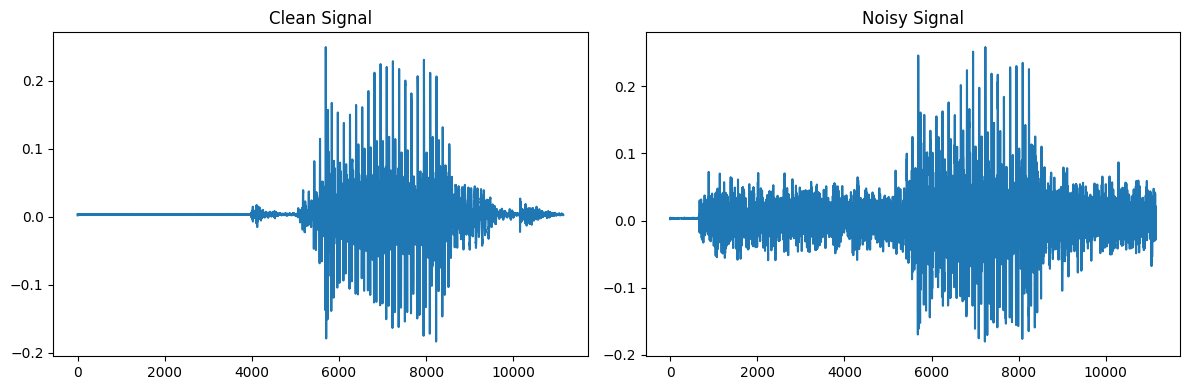

In [ ]:
test_file = os.path.join(dataset_path, "on", os.listdir(os.path.join(dataset_path, "on"))[0])
clean_signal, sr = librosa.load(test_file, sr=16000)

# Mix in background noise
noisy_signal = add_background_noise(clean_signal, background_noises, snr_db=5)

# Plot original vs noisy signal
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.title("Clean Signal")
plt.plot(clean_signal)
plt.subplot(1, 2, 2)
plt.title("Noisy Signal")
plt.plot(noisy_signal)
plt.tight_layout()
plt.show()

In [ ]:
print("🔍 Comparing models...")

svm_acc = accuracy_score(y_test, y_pred_svm)
rf_acc = accuracy_score(y_test, y_pred_rf)

print(f"🧠 SVM Accuracy: {svm_acc:.2f}")
print(f"🌲 Random Forest Accuracy: {rf_acc:.2f}")

if svm_acc > rf_acc:
    print("✅ SVM performs better!")
else:
    print("✅ Random Forest performs better!")

🔍 Comparing models...
🧠 SVM Accuracy: 0.72
🌲 Random Forest Accuracy: 0.85
✅ Random Forest performs better!


In [ ]:
import os
import librosa
import numpy as np
import random
from sklearn.preprocessing import LabelEncoder

dataset_path = "/content/speech_commands"
background_path = os.path.join(dataset_path, "_background_noise_")
max_samples_per_class = 500
max_pad_len = 32

labels = []
features = []

# Load background noise into memory
background_files = [f for f in os.listdir(background_path) if f.endswith(".wav")]
background_noises = [librosa.load(os.path.join(background_path, f), sr=16000)[0] for f in background_files]

print("🎧 Loaded background noises:", background_files)

# Helper to mix background noise
def add_background_noise(signal, noise_list, snr_db=10):
    noise = random.choice(noise_list)
    if len(noise) < len(signal):
        noise = np.tile(noise, int(np.ceil(len(signal) / len(noise))))
    noise = noise[:len(signal)]
    signal_power = np.mean(signal**2)
    noise_power = np.mean(noise**2)
    scaling = np.sqrt(signal_power / (10**(snr_db / 10) * noise_power))
    noisy_signal = signal + noise * scaling
    return noisy_signal

# Extract MFCCs
def extract_mfcc(signal, sr=16000, max_pad_len=32):
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
    if mfcc.shape[1] < max_pad_len:
        pad_width = max_pad_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0, 0), (0, pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_pad_len]
    return mfcc

# Process "on" and "off" samples
for label in ['on', 'off']:
    folder_path = os.path.join(dataset_path, label)
    files = os.listdir(folder_path)[:max_samples_per_class]

    for filename in files:
        file_path = os.path.join(folder_path, filename)
        try:
            signal, sr = librosa.load(file_path, sr=16000)

            if random.random() < 0.5:
                signal = add_background_noise(signal, background_noises, snr_db=5)

            mfcc = extract_mfcc(signal)
            features.append(mfcc)
            labels.append(label)

        except Exception as e:
            print(f"⚠️ Skipping {filename}: {e}")

🎧 Loaded background noises: ['running_tap.wav', 'exercise_bike.wav', 'doing_the_dishes.wav', 'pink_noise.wav', 'dude_miaowing.wav', 'white_noise.wav']


In [ ]:
X = np.array(features)
y = np.array(labels)

# Encode labels: 'on' → 1, 'off' → 0
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

np.save("X_mfcc_with_noise.npy", X)
np.save("y_labels_with_noise.npy", y_encoded)

print("✅ Preprocessing with noise complete and saved!")

✅ Preprocessing with noise complete and saved!


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X = np.load("X_mfcc_with_noise.npy")
y = np.load("y_labels_with_noise.npy")
X_flat = X.reshape(X.shape[0], -1)

X_train, X_test, y_train, y_test = train_test_split(X_flat, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print("📊 Report on noisy+clean trained model:")
print(classification_report(y_test, y_pred))
print("✅ Accuracy:", accuracy_score(y_test, y_pred))

📊 Report on noisy+clean trained model:
              precision    recall  f1-score   support

           0       0.75      0.77      0.76       104
           1       0.74      0.73      0.74        96

    accuracy                           0.75       200
   macro avg       0.75      0.75      0.75       200
weighted avg       0.75      0.75      0.75       200

✅ Accuracy: 0.75


In [ ]:
import joblib
joblib.dump(rf_model, "rf_model_noisy_and_clean.pkl")
print("💾 Model saved as rf_model_noisy_and_clean.pkl")

💾 Model saved as rf_model_noisy_and_clean.pkl


In [ ]:
!pip install python-kasa

from kasa import Discover
import asyncio

BULB_IP = "192.168.0.100"

async def control_bulb():
    bulb = await Discover.discover_single(BULB_IP)
    await bulb.update()

    print("Turning ON bulb...")
    await bulb.turn_on()

    await asyncio.sleep(5)

    print("Turning OFF bulb...")
    await bulb.turn_off()

await control_bulb()

TimeoutError: Timed out getting discovery response for 192.168.0.100

In [ ]:
ping 192.168.0.100

SyntaxError: invalid syntax (<ipython-input-46-6cd423cd8da4>, line 1)

In [ ]:
from kasa import SmartBulb
import asyncio

async def control_bulb():
    bulb = SmartBulb("192.168.0.100")

    try:
        await bulb.update(timeout=10)
        await bulb.turn_on()
        print("✅ Bulb Turned On Successfully!")
    except TimeoutError as e:
        print(f"❌ TimeoutError: {e}")
    except Exception as e:
        print(f"❌ An error occurred: {e}")

await control_bulb()

❌ An error occurred: IotDevice.update() got an unexpected keyword argument 'timeout'


<ipython-input-43-680aaa8069fa>:1: DeprecationWarning: SmartBulb is deprecated, use IotBulb from package kasa.iot instead or use Discover.discover_single() and Device.connect() to support new protocols
  from kasa import SmartBulb


In [1]:
from kasa import Discover
import asyncio

async def find_bulbs():
    devices = await Discover.discover()
    for addr, dev in devices.items():
        print(f"Found device at {addr}: {dev}")

await find_bulbs()

ModuleNotFoundError: No module named 'kasa'